In [20]:
import duckdb
import pandas as pd
import seaborn as sns
from pprint import pprint

In [21]:
con = duckdb.connect("/home/etienne/projects/inatML/data/inat.duckdb")
df = con.execute("SELECT * FROM features.training").df()
con.close()

In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 37924 entries, 0 to 37923
Data columns (total 38 columns):
 #   Column                     Non-Null Count  Dtype          
---  ------                     --------------  -----          
 0   observation_id             37924 non-null  uint64         
 1   user_id                    37924 non-null  uint64         
 2   label                      37924 non-null  bool           
 3   photo_count                37924 non-null  int64          
 4   has_description            37924 non-null  bool           
 5   has_tags                   37924 non-null  bool           
 6   tag_count                  37924 non-null  int64          
 7   has_license                37924 non-null  bool           
 8   positional_accuracy_m      30118 non-null  Int64          
 9   obscured                   37924 non-null  bool           
 10  geoprivacy_set             37924 non-null  bool           
 11  captive                    37924 non-null  bool           
 12  o

In [35]:
#Nans
for col in df.columns:
    if df[col].hasnans:
        print(round(df[col].isnull().sum() * 100 / len(df[col]),2), "%  ", col)



20.58 %   positional_accuracy_m
42.93 %   oauth_application_id
43.15 %   observed_hour
16.29 %   rg_rate_last_12m
1.69 %   sampling_pool
0.03 %   ids_given_count


In [36]:
df.describe()

,observation_id,user_id,photo_count,tag_count,positional_accuracy_m,oauth_application_id,obs_to_submit_lag_days,observed_month,observed_week,observed_hour,...,taxon_diversity_family,taxon_diversity_genus,taxon_diversity_species,avg_photo_count,pct_obs_with_description,pct_obs_with_license,pct_obs_from_mobile,ids_given_count,taxon_rg_rate,taxon_popularity_rank
count,3.792400e+04,3.792400e+04,37924.00000,37924.000000,30118.0,21644.0,37924,37924.000000,37924.000000,21558.0,...,37924.000000,37924.000000,37924.000000,37924.000000,37924.000000,37924.000000,37924.000000,37911.0,37924.000000,37924.000000
mean,1.650348e+08,2.369700e+06,1.91156,1.030587,2154.858424,49.452689,161 days 19:51:42.197816,7.011207,28.603628,12.384776,...,47.165041,89.391995,93.949188,1.913916,0.095987,0.784055,0.315622,230.224183,0.691982,1.584419
std,9.808092e+07,1.978351e+06,1.63515,9.827747,45815.800722,177.832089,624 days 15:23:55.620004,1.736333,7.491798,4.118312,...,27.292433,69.597009,87.192962,1.014422,0.176661,0.409877,0.413148,1031.265563,0.338880,0.550856
min,9.783400e+04,5.610000e+02,0.00000,0.000000,0.0,2.0,-1 days +20:26:44,1.000000,1.000000,0.0,...,5.000000,5.000000,7.000000,0.600000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
25%,7.845194e+07,1.006060e+06,1.00000,0.000000,5.0,2.0,0 days 16:09:20.750000,6.000000,23.000000,10.0,...,28.000000,41.000000,37.000000,1.122807,0.000000,1.000000,0.000000,0.0,0.500000,1.255273
50%,1.648930e+08,1.985846e+06,1.00000,0.000000,15.0,3.0,0 days 23:43:24.500000,7.000000,29.000000,13.0,...,41.000000,67.000000,63.000000,1.500000,0.018088,1.000000,0.007335,2.0,0.839506,1.716003
75%,2.448144e+08,3.060142e+06,2.00000,0.000000,91.75,3.0,7 days 12:58:01.500000,8.000000,34.000000,15.0,...,60.000000,114.000000,120.000000,2.478261,0.094298,1.000000,0.765152,44.0,0.976744,2.000000
max,3.409483e+08,9.979691e+06,28.00000,280.000000,3217612.0,843.0,5723 days 14:34:13,12.000000,53.000000,23.0,...,126.000000,296.000000,410.000000,5.166667,1.000000,1.000000,1.000000,7056.0,1.000000,2.574031


<Axes: xlabel='label', ylabel='Percent'>

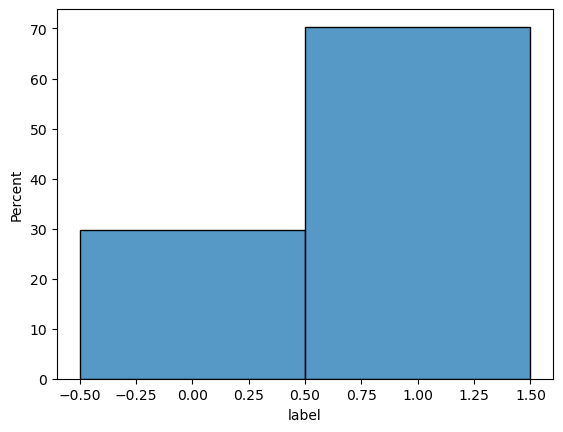

In [42]:
sns.histplot(df, x='label', stat='percent', discrete=True)

In [43]:
print(df['user_id'].nunique())

585
